# Data Loading & Quality Checks — Malaysian PDM dataset
### Role 1: counts per class, sizes, colour mode,
### corrupted files, duplicates, balance.

In [8]:
import os, hashlib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

CLASSES = ["Low Potential Dysgraphia", "Potential Dysgraphia"]
BASE = "../data"

In [9]:
# count images per class (balance check)
counts = {}
for cls in CLASSES:
    fs = [f for f in os.listdir(os.path.join(BASE, cls))
          if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    counts[cls] = len(fs)
print(counts, "| total:", sum(counts.values()))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data\\Low Potential Dysgraphia'

In [ ]:
# loop every image: size, mode, corrupted?, md5 for duplicates
rows = []
for cls in CLASSES:
    folder = os.path.join(BASE, cls)
    for f in sorted(os.listdir(folder)):
        if not f.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        path = os.path.join(folder, f)
        try:
            with Image.open(path) as im:
                w, h = im.size
                mode = im.mode
            ok = True
        except Exception:
            w, h, mode, ok = 0, 0, "CORRUPTED", False
        md5 = hashlib.md5(open(path, "rb").read()).hexdigest()
        rows.append({"class": cls, "file": f, "width": w, "height": h,
                     "mode": mode, "ok": ok, "md5": md5})
df = pd.DataFrame(rows)
df["aspect"] = df["width"] / df["height"].clip(lower=1)

In [ ]:
# the image version of shape() and describe()
print("shape:", df.shape)
print("corrupted:", df[~df.ok]["file"].tolist())
print("duplicates:", df[df.md5.duplicated()]["file"].tolist())
df[["width", "height", "aspect"]].describe()

shape: (249, 8)
corrupted: []
duplicates: []


,width,height,aspect
count,249.000000,249.000000,249.000000
mean,1090.586345,173.939759,7.041890
std,244.593197,78.864423,2.186672
min,396.000000,55.000000,3.020089
25%,918.000000,102.000000,5.306452
50%,1204.000000,164.000000,6.948980
75%,1258.000000,230.000000,8.102564
max,1434.000000,448.000000,14.238636


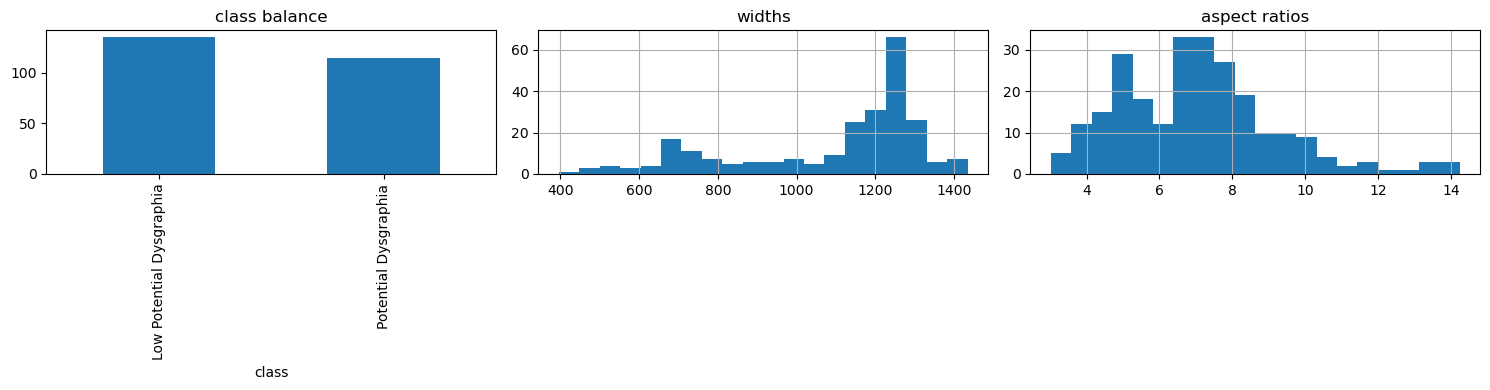

In [ ]:
# balance + distributions (template asks for plots)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["class"].value_counts().plot.bar(ax=ax[0]); ax[0].set_title("class balance")
df["width"].hist(bins=20, ax=ax[1]); ax[1].set_title("widths")
df["aspect"].hist(bins=20, ax=ax[2]); ax[2].set_title("aspect ratios")
plt.tight_layout()
plt.show()

## Quality summary (Malaysian PDM)
- **Uniformity:** all grayscale ("L") jpgs, white ink on black background
- **Consistency:** two folders, naming style LPD/PD + number
- **Completeness:** corrupted = [] (none)
- **Accuracy:** labels come from psychologist assessment (trusted source)
- **Validity:** widths 396–1434 px, aspect 3–14 → long strips ⇒ padding needed before modeling
- **Uniqueness:** duplicates = [] (none)
- **Shape/balance:** 249 total (135 Low / 114 Potential) → mild imbalance ⇒ stratified splits